In [1]:
%pip install tensorflow==2.14

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"

import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-04-14 03:42:46.889922: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-14 03:42:46.890001: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-14 03:42:46.890058: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-14 03:42:46.903429: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-14 03:42:48.217242: W tensorflow/compiler/

Num GPUs Available:  2


## Prepare Data

In [3]:
import json
import random
from tokenizer import build_dataset

# Prepare dataset (tokenizer)
SNIPPET_DATAPATH = "./snippets"
DATASET_FILEPATH = "./dataset.json"

# Load dataset
with open(DATASET_FILEPATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)
    dataset = [d for d in dataset if "{" not in d and "}" not in d]
    dataset = dataset[:100]

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Sample dataset with multiple properties
# Format: (text, property1, property2, ...)
def build_vocabularies(dataset):
    """Build vocabularies for words and each property type."""
    word_vocab = set()
    property_vocabs = []  # List of sets, one for each property type
    
    # Initialize property vocabularies
    num_properties = len(dataset[0]) - 1
    property_vocabs = [set() for _ in range(num_properties)]
    
    for item in dataset:
        words = item[0].split()
        word_vocab.update(words)
        
        for prop_idx in range(num_properties):
            properties = item[prop_idx+1].split()
            property_vocabs[prop_idx].update(properties)
    
    return word_vocab, property_vocabs

word_vocab, property_vocabs = build_vocabularies(dataset)

# Create mappings for words and each property type
word_to_idx = {word: i+1 for i, word in enumerate(word_vocab)}  # 0 for padding
idx_to_word = {i: word for word, i in word_to_idx.items()}

property_to_idx = []
idx_to_property = []
for vocab in property_vocabs:
    prop_map = {prop: i+1 for i, prop in enumerate(vocab)}
    idx_prop = {i: prop for prop, i in prop_map.items()}
    property_to_idx.append(prop_map)
    idx_to_property.append(idx_prop)

word_vocab_size = len(word_to_idx) + 1
property_vocab_sizes = [len(p) + 1 for p in property_to_idx]

def prepare_sequences(dataset):
    """Prepare training sequences with words and all properties."""
    X_words = []
    X_properties = [[] for _ in range(len(property_vocabs))]  # List of lists for each property
    y_word = []
    y_properties = [[] for _ in range(len(property_vocabs))]
    
    for item in dataset:
        words = item[0].split()
        word_ids = [word_to_idx[word] for word in words]
        
        # Get all property sequences
        prop_sequences = []
        for prop_idx in range(len(property_vocabs)):
            # Check if we have enough properties for this item
            if prop_idx + 1 >= len(item):
                raise ValueError(f"Item missing property {prop_idx + 1}: {item}")
                
            props = item[prop_idx + 1].split()
            # Verify property sequence length matches word sequence length
            if len(props) != len(words):
                raise ValueError(
                    f"Property {prop_idx + 1} length ({len(props)}) doesn't match word length ({len(words)}) in: {item}"
                )
                
            prop_ids = [property_to_idx[prop_idx][prop] for prop in props]
            prop_sequences.append(prop_ids)
        
        # Create training sequences
        for i in range(1, len(words)):
            X_words.append(word_ids[:i])
            for prop_idx in range(len(property_vocabs)):
                X_properties[prop_idx].append(prop_sequences[prop_idx][:i])
            
            y_word.append(word_ids[i])
            for prop_idx in range(len(property_vocabs)):
                y_properties[prop_idx].append(prop_sequences[prop_idx][i])
    
    return X_words, X_properties, y_word, y_properties

X_words, X_properties, y_word, y_properties = prepare_sequences(dataset)

# Pad sequences
max_sequence_length = max(len(seq) for seq in X_words)
X_words_padded = tf.keras.preprocessing.sequence.pad_sequences(X_words, maxlen=max_sequence_length, padding='pre')

X_properties_padded = []
for props in X_properties:
    padded = tf.keras.preprocessing.sequence.pad_sequences(props, maxlen=max_sequence_length, padding='pre')
    X_properties_padded.append(padded)

# Convert targets to one-hot
y_word_onehot = to_categorical(y_word, num_classes=word_vocab_size)
y_properties_onehot = []
for props, vocab_size in zip(y_properties, property_vocab_sizes):
    onehot = to_categorical(props, num_classes=vocab_size)
    y_properties_onehot.append(onehot)

# Split data
split_data = train_test_split(X_words_padded, *X_properties_padded, y_word_onehot, *y_properties_onehot, 
                             test_size=0.2, random_state=42)

X_train_words = split_data[0]
X_test_words = split_data[1]

X_train_props = []
X_test_props = []
for i in range(len(property_vocabs)):
    X_train_props.append(split_data[2 + i*2])
    X_test_props.append(split_data[3 + i*2])

y_train_word = split_data[2 + len(property_vocabs)*2]
y_test_word = split_data[3 + len(property_vocabs)*2]

y_train_props = []
y_test_props = []
offset = 4 + len(property_vocabs)*2
for i in range(len(property_vocabs)):
    y_train_props.append(split_data[offset + i*2])
    y_test_props.append(split_data[offset + 1 + i*2])

## Model

### LSTM Model

In [20]:
def create_lstm_model(word_vocab_size, property_vocab_sizes, 
                              word_embed_dim=64, prop_embed_dims=32, lstm_units=128):
    """Create a model that handles multiple properties."""
    if isinstance(prop_embed_dims, int):
        prop_embed_dims = [prop_embed_dims] * len(property_vocab_sizes)
    
    # Word input
    word_input = Input(shape=(None,), name='word_input')
    word_embed = Embedding(word_vocab_size, word_embed_dim, name='word_embedding')(word_input)
    
    # Property inputs
    prop_inputs = []
    prop_embeds = []
    for i, (vocab_size, embed_dim) in enumerate(zip(property_vocab_sizes, prop_embed_dims)):
        prop_input = Input(shape=(None,), name=f'property_{i}_input')
        prop_embed = Embedding(vocab_size, embed_dim, name=f'property_{i}_embedding')(prop_input)
        prop_inputs.append(prop_input)
        prop_embeds.append(prop_embed)
    
    # Combine all embeddings
    combined = Concatenate()([word_embed] + prop_embeds)
    
    # LSTM layer
    lstm_out = LSTM(lstm_units)(combined)
    
    # Outputs: word + each property
    outputs = []
    word_output = Dense(word_vocab_size, activation='softmax', name='word_output')(lstm_out)
    outputs.append(word_output)
    
    for i, vocab_size in enumerate(property_vocab_sizes):
        prop_output = Dense(vocab_size, activation='softmax', name=f'property_{i}_output')(lstm_out)
        outputs.append(prop_output)
    
    model = Model(inputs=[word_input] + prop_inputs, outputs=outputs)
    return model


### Attention Model

In [21]:
from tensorflow.keras.layers import Input, Embedding, Dense, Concatenate, LayerNormalization, Dropout, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def create_attention_model(word_vocab_size, property_vocab_sizes, 
                           word_embed_dim=64, prop_embed_dims=32, 
                           num_heads=4, ff_dim=128, dropout_rate=0.1):
    
    if isinstance(prop_embed_dims, int):
        prop_embed_dims = [prop_embed_dims] * len(property_vocab_sizes)
    
    # Total embedding dimension = word + all properties
    embed_dim = word_embed_dim + sum(prop_embed_dims)

    # Word input
    word_input = Input(shape=(None,), name='word_input')
    word_embed = Embedding(word_vocab_size, word_embed_dim, name='word_embedding')(word_input)

    # Property inputs
    prop_inputs = []
    prop_embeds = []
    for i, (vocab_size, embed_dim) in enumerate(zip(property_vocab_sizes, prop_embed_dims)):
        prop_input = Input(shape=(None,), name=f'property_{i}_input')
        prop_embed = Embedding(vocab_size, embed_dim, name=f'property_{i}_embedding')(prop_input)
        prop_inputs.append(prop_input)
        prop_embeds.append(prop_embed)

    # Combine embeddings
    combined = Concatenate()([word_embed] + prop_embeds)

    # Self-attention layer
    attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=combined.shape[-1]//num_heads)(combined, combined)
    attn_out = Dropout(dropout_rate)(attn_out)
    attn_out = LayerNormalization(epsilon=1e-6)(combined + attn_out)

    # Feed-forward network
    ff_out = Dense(ff_dim, activation='relu')(attn_out)
    ff_out = Dense(combined.shape[-1])(ff_out)
    ff_out = Dropout(dropout_rate)(ff_out)
    ff_out = LayerNormalization(epsilon=1e-6)(attn_out + ff_out)

    # Global pooling
    pooled = GlobalAveragePooling1D()(ff_out)

    # Output layers
    outputs = []
    word_output = Dense(word_vocab_size, activation='softmax', name='word_output')(pooled)
    outputs.append(word_output)

    for i, vocab_size in enumerate(property_vocab_sizes):
        prop_output = Dense(vocab_size, activation='softmax', name=f'property_{i}_output')(pooled)
        outputs.append(prop_output)

    model = Model(inputs=[word_input] + prop_inputs, outputs=outputs)
    return model, embed_dim


## Training

### Attention Model Training

In [22]:
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import EarlyStopping

# Create model
num_heads = 4
ff_dim = 128
dropout_rate = 0.1
epochs = 200
batch_size = 32
early_stop_patience = epochs # No early stop
prop_embed_dims = [32, 16, 16]  # customize embedding size for each property
att_model, embed_dim = create_attention_model(word_vocab_size, property_vocab_sizes, 
                                prop_embed_dims=prop_embed_dims,
                                num_heads=num_heads,
                                ff_dim=ff_dim,
                                dropout_rate=dropout_rate
)

# Compile model
losses = {'word_output': 'categorical_crossentropy'}
metrics = {'word_output': 'accuracy'}
for i in range(len(property_vocab_sizes)):
    losses[f'property_{i}_output'] = 'categorical_crossentropy'
    metrics[f'property_{i}_output'] = 'accuracy'

att_model.compile(optimizer='adam', loss=losses, metrics=metrics)

# Prepare training data
train_input = {'word_input': X_train_words}
test_input = {'word_input': X_test_words}

for i in range(len(X_train_props)):
    train_input[f'property_{i}_input'] = X_train_props[i]
    test_input[f'property_{i}_input'] = X_test_props[i]

train_output = {'word_output': y_train_word}
test_output = {'word_output': y_test_word}

for i in range(len(y_train_props)):
    train_output[f'property_{i}_output'] = y_train_props[i]
    test_output[f'property_{i}_output'] = y_test_props[i]

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=early_stop_patience,
    restore_best_weights=True
)

# Train the model
att_history = att_model.fit(
    train_input,
    train_output,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(test_input, test_output),
    callbacks=[early_stop]
)


Epoch 1/200
33/33 [==============================] - 7s 97ms/step - loss: 4.3233 - word_output_loss: 3.4657 - property_0_output_loss: 0.8576 - word_output_accuracy: 0.1152 - property_0_output_accuracy: 0.7466 - val_loss: 4.1283 - val_word_output_loss: 3.3972 - val_property_0_output_loss: 0.7311 - val_word_output_accuracy: 0.1418 - val_property_0_output_accuracy: 0.7471
Epoch 2/200
33/33 [==============================] - 1s 34ms/step - loss: 3.7838 - word_output_loss: 3.1117 - property_0_output_loss: 0.6721 - word_output_accuracy: 0.1603 - property_0_output_accuracy: 0.7850 - val_loss: 4.1181 - val_word_output_loss: 3.4019 - val_property_0_output_loss: 0.7161 - val_word_output_accuracy: 0.1418 - val_property_0_output_accuracy: 0.7471
Epoch 3/200
33/33 [==============================] - 1s 23ms/step - loss: 3.7432 - word_output_loss: 3.0814 - property_0_output_loss: 0.6618 - word_output_accuracy: 0.1612 - property_0_output_accuracy: 0.7850 - val_loss: 4.0803 - val_word_output_loss: 3.35

### LSTM Model Training

In [24]:
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import EarlyStopping

# Create model
epochs = 200
batch_size = 32
early_stop_patience = epochs # 5
prop_embed_dims = [32, 16, 16]  # Can customize embedding size for each property
lstm_model = create_lstm_model(word_vocab_size, property_vocab_sizes, 
                                   prop_embed_dims=prop_embed_dims)

# Compile model
losses = {'word_output': 'categorical_crossentropy'}
metrics = {'word_output': 'accuracy'}
for i in range(len(property_vocab_sizes)):
    losses[f'property_{i}_output'] = 'categorical_crossentropy'
    metrics[f'property_{i}_output'] = 'accuracy'

lstm_model.compile(optimizer='adam', loss=losses, metrics=metrics)

# Prepare training data
train_input = {'word_input': X_train_words}
test_input = {'word_input': X_test_words}

for i in range(len(X_train_props)):
    train_input[f'property_{i}_input'] = X_train_props[i]
    test_input[f'property_{i}_input'] = X_test_props[i]

train_output = {'word_output': y_train_word}
test_output = {'word_output': y_test_word}

for i in range(len(y_train_props)):
    train_output[f'property_{i}_output'] = y_train_props[i]
    test_output[f'property_{i}_output'] = y_test_props[i]


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=early_stop_patience,
    restore_best_weights=True
)

# Train the model
lstm_history = lstm_model.fit(
    train_input,
    train_output,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(test_input, test_output),
    callbacks=[early_stop]
)

Epoch 1/200
33/33 [==============================] - 6s 90ms/step - loss: 4.6077 - word_output_loss: 3.7051 - property_0_output_loss: 0.9026 - word_output_accuracy: 0.1056 - property_0_output_accuracy: 0.7630 - val_loss: 4.1764 - val_word_output_loss: 3.4327 - val_property_0_output_loss: 0.7437 - val_word_output_accuracy: 0.1149 - val_property_0_output_accuracy: 0.7471
Epoch 2/200
33/33 [==============================] - 1s 26ms/step - loss: 3.8028 - word_output_loss: 3.1373 - property_0_output_loss: 0.6655 - word_output_accuracy: 0.1497 - property_0_output_accuracy: 0.7850 - val_loss: 4.0691 - val_word_output_loss: 3.3718 - val_property_0_output_loss: 0.6973 - val_word_output_accuracy: 0.1418 - val_property_0_output_accuracy: 0.7471
Epoch 3/200
33/33 [==============================] - 1s 26ms/step - loss: 3.6735 - word_output_loss: 3.0483 - property_0_output_loss: 0.6251 - word_output_accuracy: 0.1814 - property_0_output_accuracy: 0.7850 - val_loss: 3.8600 - val_word_output_loss: 3.24

## Comparation

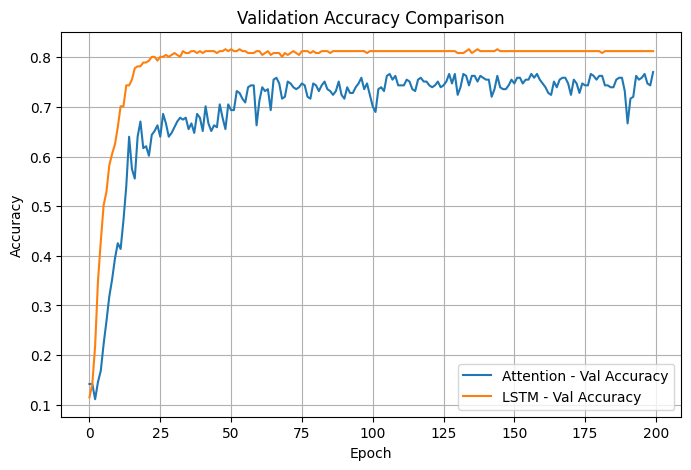

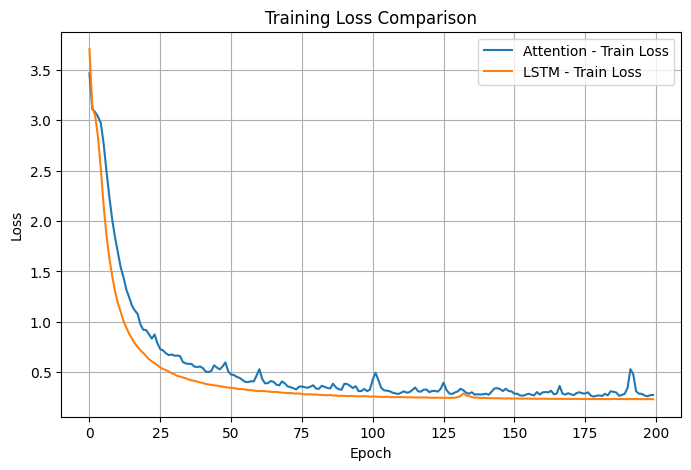

In [25]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(att_history.history['val_word_output_accuracy'], label='Attention - Val Accuracy')
plt.plot(lstm_history.history['val_word_output_accuracy'], label='LSTM - Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(att_history.history['word_output_loss'], label='Attention - Train Loss')
plt.plot(lstm_history.history['word_output_loss'], label='LSTM - Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
# # Modify the Model to Output Attention Weights
# attn_layer = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads, name='multihead_attention')
# attn_output, attn_weights = attn_layer(embed, embed, return_attention_scores=True)

# # Build a Submodel to Extract Attention Weights
# from tensorflow.keras.models import Model
# attention_model = Model(inputs=model.input, outputs=model.get_layer('multihead_attention').output[1])

# # Run the Model on a Sample and Get Attention Weights
# sample_input = {k: v[:1] for k, v in test_input.items()}  # get a single example
# attn_scores = attention_model.predict(sample_input)  # shape: (1, num_heads, seq_len, seq_len)

# # Visualize Attention as a Heatmap
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# # Choose one head
# head = 0
# attention_matrix = attn_scores[0][head]  # shape: (seq_len, seq_len)

# # Optional: get token names for labels
# tokens = X_test_words[0]  # assuming this has token ids
# token_names = [id_to_word[idx] for idx in tokens]  # map ids to string tokens

# plt.figure(figsize=(10, 8))
# sns.heatmap(attention_matrix, xticklabels=token_names, yticklabels=token_names, cmap='viridis')
# plt.title(f'Attention Heatmap - Head {head}')
# plt.xlabel('Key Positions')
# plt.ylabel('Query Positions')
# plt.show()